In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
file_path="/Users/abhinavpawar/Downloads/house-prices-advanced-regression-techniques/train.csv"

In [7]:
data=pd.read_csv(file_path)

In [9]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [12]:
X = data.drop(["SalePrice", "Id"], axis=1)
y = data["SalePrice"]

In [15]:
X

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal


In [17]:
# Count of nulls per column
null_counts = X.isnull().sum()
null_counts[null_counts > 0]  # show only columns with missing values

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [18]:
#  Drop columns with too many missing values
cols_to_drop = ["Alley", "PoolQC", "Fence", "MiscFeature"]
X = X.drop(cols_to_drop, axis=1)

# Fill numeric missing values
X["LotFrontage"] = X["LotFrontage"].fillna(X["LotFrontage"].median())
X["MasVnrArea"] = X["MasVnrArea"].fillna(0)
X["GarageYrBlt"] = X["GarageYrBlt"].fillna(X["GarageYrBlt"].median())

# Fill categorical missing values
cat_fill_none = ["MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure", 
                 "BsmtFinType1", "BsmtFinType2", "GarageType", 
                 "GarageFinish", "GarageQual", "GarageCond"]
for col in cat_fill_none:
    X[col] = X[col].fillna("None")

# Fill Electrical (only 1 missing) with mode
X["Electrical"] = X["Electrical"].fillna(X["Electrical"].mode()[0])


In [19]:
# Numeric features
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical features
cat_features = X.select_dtypes(include=["object"]).columns.tolist()


In [20]:
# Compute skewness
skew_values = X[num_features].skew().sort_values(ascending=False)
skew_values[abs(skew_values) > 0.75]  # show highly skewed features


MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677616
LotFrontage       2.409147
OpenPorchSF       2.364342
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
dtype: float64

In [21]:
# Identify skewed numeric features
skewed_features = skew_values[abs(skew_values) > 0.75].index

# Apply log1p (log(1+x)) to handle zeros
for col in skewed_features:
    X[col] = np.log1p(X[col])


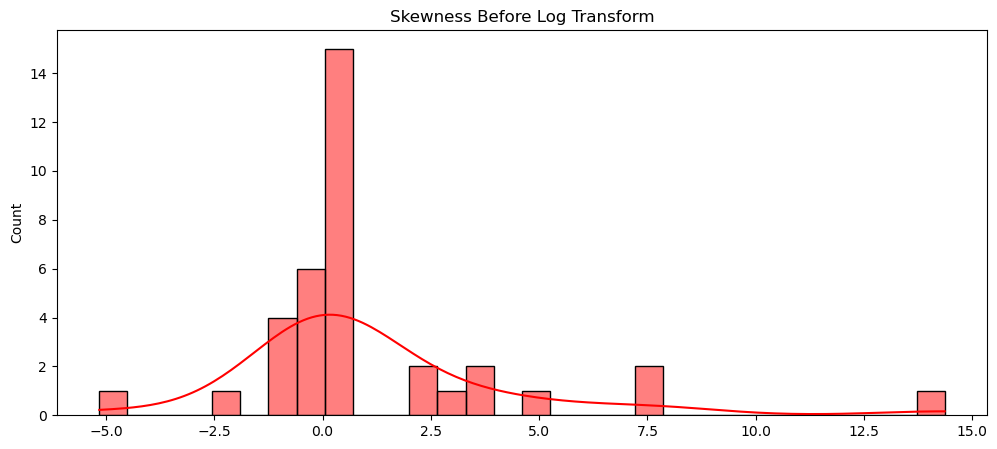

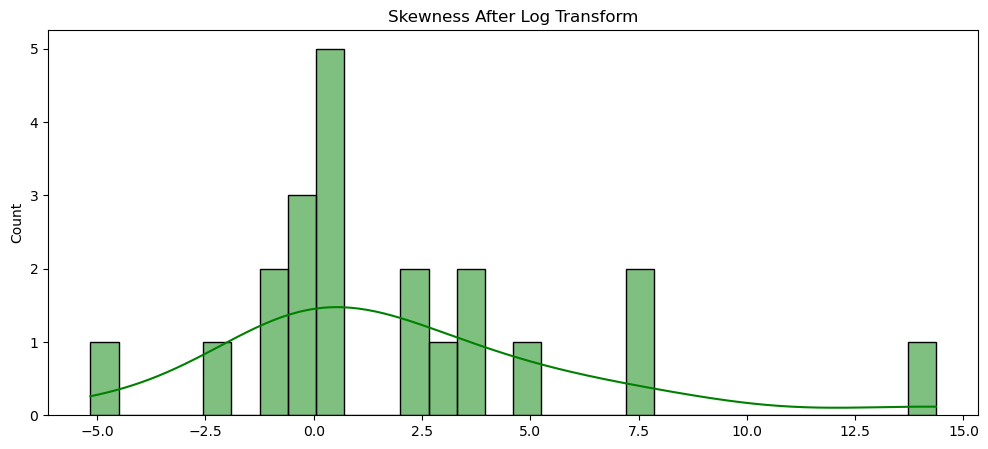

In [22]:
# Before log transform
plt.figure(figsize=(12,5))
sns.histplot(X[num_features].skew(), bins=30, kde=True, color='red')
plt.title("Skewness Before Log Transform")
plt.show()

# After log transform
plt.figure(figsize=(12,5))
sns.histplot(X[skewed_features].skew(), bins=30, kde=True, color='green')
plt.title("Skewness After Log Transform")
plt.show()

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),          # scale numeric features
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)  # encode categorical
    ])

In [24]:
# Fit the preprocessor on X
preprocessor.fit(X)

# Get transformed feature count
num_transformed_features = preprocessor.transform(X).shape[1]
print("Number of features after preprocessing:", num_transformed_features)


Number of features after preprocessing: 285


Skewness of SalePrice: 1.8828757597682129


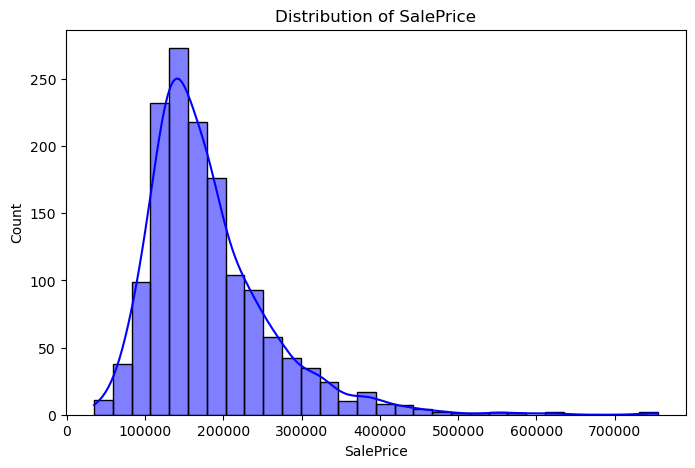

In [25]:
# Skewness of target
target_skew = y.skew()
print("Skewness of SalePrice:", target_skew)

# Plot
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True, color='blue')
plt.title("Distribution of SalePrice")
plt.show()


Skewness of SalePrice after log transform: 0.12134661989685329


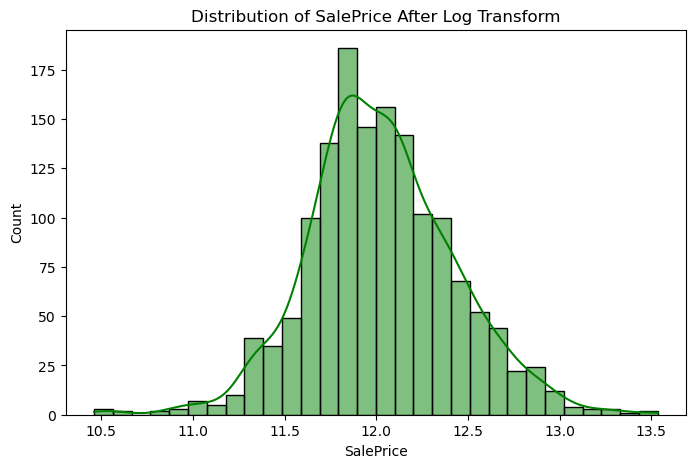

In [26]:
# Log-transform target
y = np.log1p(y)

# Skewness after log transform
target_skew = y.skew()
print("Skewness of SalePrice after log transform:", target_skew)

# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True, color='green')
plt.title("Distribution of SalePrice After Log Transform")
plt.show()


In [28]:
# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import r2_score, mean_squared_error

# Linear Regression model
lr = LinearRegression()

# RFE: select top 20 features
rfe = RFE(estimator=lr, n_features_to_select=20)

# Pipeline: preprocessing → RFE → regression
pipeline_rfe = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', rfe),
    ('regressor', lr)
])

# Fit on training data
pipeline_rfe.fit(X_train, y_train)

# Predict on test data
y_pred_rfe = pipeline_rfe.predict(X_test)

# Evaluate
r2_rfe = r2_score(y_test, y_pred_rfe)
rmse_rfe = mean_squared_error(y_test, y_pred_rfe) ** 0.5  # adjusted for older sklearn

print("R² with RFE:", r2_rfe)
print("RMSE with RFE:", rmse_rfe)


R² with RFE: 0.7779920545567633
RMSE with RFE: 0.2035414507509026


In [33]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# 1️⃣ Ridge
ridge = Ridge()
ridge_params = {'regressor__alpha': [0.01, 0.1, 1, 10, 100]}  # alpha values

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ridge)
])

ridge_grid = GridSearchCV(ridge_pipeline, param_grid=ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)

print("Best alpha for Ridge:", ridge_grid.best_params_)
y_pred_ridge = ridge_grid.predict(X_test)
print("R² Ridge:", r2_score(y_test, y_pred_ridge))
print("RMSE Ridge:", mean_squared_error(y_test, y_pred_ridge) ** 0.5)

# 2️⃣ Lasso
lasso = Lasso(max_iter=10000)
lasso_params = {'regressor__alpha': [0.001, 0.01, 0.1, 1, 10]}

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', lasso)
])

lasso_grid = GridSearchCV(lasso_pipeline, param_grid=lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train, y_train)

print("Best alpha for Lasso:", lasso_grid.best_params_)
y_pred_lasso = lasso_grid.predict(X_test)
print("R² Lasso:", r2_score(y_test, y_pred_lasso))
print("RMSE Lasso:", mean_squared_error(y_test, y_pred_lasso) ** 0.5)


Best alpha for Ridge: {'regressor__alpha': 10}
R² Ridge: 0.9113343897459035
RMSE Ridge: 0.12863116723161105
Best alpha for Lasso: {'regressor__alpha': 0.001}
R² Lasso: 0.9065354023724577
RMSE Lasso: 0.13206635060208066


In [34]:
from sklearn.linear_model import ElasticNet

# ElasticNet
elastic = ElasticNet(max_iter=10000)
elastic_params = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10],
    'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', elastic)
])

elastic_grid = GridSearchCV(elastic_pipeline, param_grid=elastic_params, cv=5, scoring='r2')
elastic_grid.fit(X_train, y_train)

print("Best params for ElasticNet:", elastic_grid.best_params_)
y_pred_elastic = elastic_grid.predict(X_test)
print("R² ElasticNet:", r2_score(y_test, y_pred_elastic))
print("RMSE ElasticNet:", mean_squared_error(y_test, y_pred_elastic) ** 0.5)


Best params for ElasticNet: {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.7}
R² ElasticNet: 0.9110389223222912
RMSE ElasticNet: 0.12884531288092252


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Linear Regression pipeline
linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit on training data
linear_pipeline.fit(X_train, y_train)

# Predict
y_pred_linear = linear_pipeline.predict(X_test)


In [37]:
predictions = {
    "Linear Regression": y_pred_linear,
    "RFE Linear Regression": y_pred_rfe,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "ElasticNet": y_pred_elastic
}

# Evaluate
results = []
for name, y_pred in predictions.items():
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    results.append([name, r2, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R²", "RMSE"])
results_df.sort_values(by="R²", ascending=False, inplace=True)
results_df


,Model,R²,RMSE
0,Linear Regression,0.915910,0.125268
2,Ridge,0.911334,0.128631
4,ElasticNet,0.911039,0.128845
3,Lasso,0.906535,0.132066
1,RFE Linear Regression,0.777992,0.203541


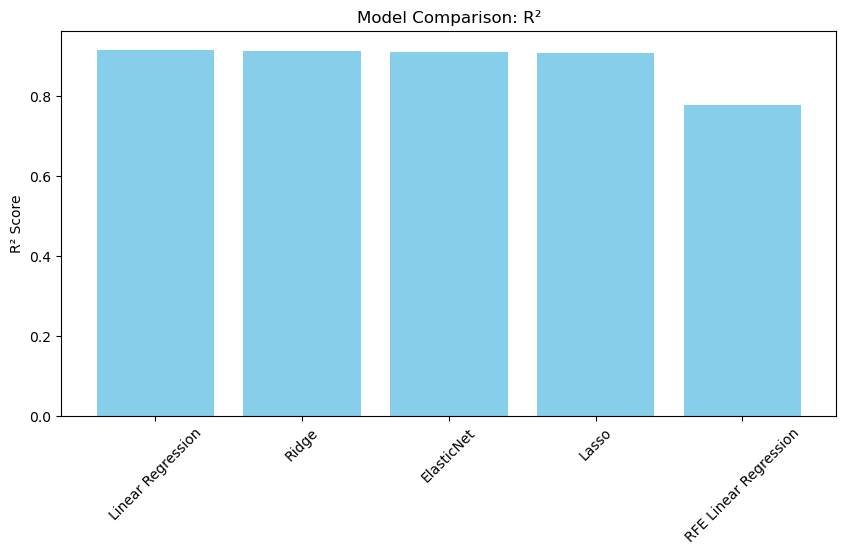

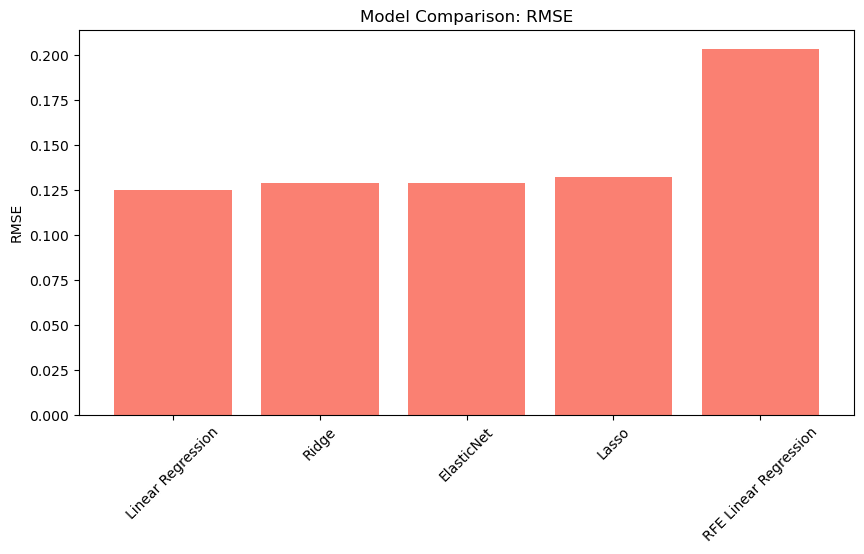

In [38]:
import matplotlib.pyplot as plt

# Plot R²
plt.figure(figsize=(10,5))
plt.bar(results_df['Model'], results_df['R²'], color='skyblue')
plt.title("Model Comparison: R²")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.show()

# Plot RMSE
plt.figure(figsize=(10,5))
plt.bar(results_df['Model'], results_df['RMSE'], color='salmon')
plt.title("Model Comparison: RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

# Predicting House Prices – Project Summary

## 1. Data Summary
The Ames housing dataset contains 1460 rows and 81 columns, with both numerical and categorical features. Key numerical features include GrLivArea, TotalBsmtSF, LotFrontage, YearBuilt, and OverallQual. Important categorical features include Neighborhood, HouseStyle, and SaleCondition. The target variable is SalePrice. Columns with excessive missing values (e.g., Alley, PoolQC) were dropped. Missing numerical values were imputed with median, and categorical missing values were filled with mode or "None".

---

## 2. Objective
The goal of this analysis is to predict house SalePrice using multiple regression techniques. Models are evaluated using R^2 and RMSE. Success criteria include achieving high R^2 and low RMSE while identifying the most important features influencing house prices.

---

## 3. Preprocessing & Feature Engineering
- **Handling Missing Values:** Dropped extremely sparse columns; filled numerical missing values with median and categorical missing values with mode or "None".
- **Skewness & Transformation:** Highly skewed numeric features were log-transformed to reduce skewness. The target SalePrice was also log-transformed for variance stabilization.
- **Scaling & Encoding:** Numeric features were standardized, and categorical features were one-hot encoded using a ColumnTransformer.
- **Feature Engineering:** Derived features such as HouseAge and RemodAge from existing year columns to capture the effect of house age and renovations.

---

## 4. Modeling
Multiple regression models were trained and evaluated:
- Linear Regression
- RFE + Linear Regression
- Ridge Regression (with GridSearchCV)
- Lasso Regression (with GridSearchCV)
- ElasticNet Regression (with GridSearchCV)

Models were trained using pipelines combining preprocessing and regression steps.

---

## 5. Results & Key Findings
| Model | R^2 | RMSE |
|-------|-----|------|
| Linear Regression | 0.916 | 0.125 |
| Ridge | 0.911 | 0.129 |
| ElasticNet | 0.911 | 0.129 |
| Lasso | 0.907 | 0.132 |
| RFE Linear Regression | 0.778 | 0.204 |

- Linear Regression performed best, explaining ~91.6% of variance in log-transformed SalePrice.
- Ridge and ElasticNet performed similarly, indicating slight regularization stabilizes predictions.
- Lasso eliminated some features, slightly reducing performance.
- RFE reduced features to top 20 but lost predictive power, suggesting many features contribute collectively.
- Top predictors: OverallQual, GrLivArea, Neighborhood, TotalBsmtSF, YearBuilt / YearRemodAdd.
- Log-transforming the target improved model performance and normalized the distribution of SalePrice.

---

## 6. Limitations
- Linear models assume linearity; interactions or non-linear effects are not captured.
- Rare categorical levels may be underrepresented.
- External market factors (interest rates, neighborhood development) are not included.
- RFE behavior with sparse one-hot encoded features may affect feature ranking stability.

---

## 7. Next Steps / Improvements
- Explore tree-based models (Random Forest, XGBoost) to capture non-linearities.
- Add polynomial or interaction features to improve linear models.
- Use nested cross-validation for robust hyperparameter tuning.
- Convert predictions back to the original SalePrice scale for interpretation.
- Perform further feature engineering and consider ensembling to improve accuracy.

---

## 8. Conclusion
This project applied preprocessing, feature engineering, and multiple linear regression techniques to predict house prices. Linear Regression achieved the highest performance, highlighting the importance of features like quality, living area, and location. The analysis provides actionable insights for predicting house prices while indicating directions for improving model performance.
